In [12]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

import pymedphys
from pymedphys._experimental.autosegmentation import filtering, indexing, mask, pipeline

In [2]:
(
    _,
    _,
    _,
    ct_uid_to_structure_uid,
    structure_uid_to_ct_uids,
    _,
    structure_names_by_ct_uid,
    structure_names_by_structure_set_uid,
    _,
    _,
) = pipeline.get_dataset_metadata()

In [3]:
structure_names = set()
for _, uid_structure_names in structure_names_by_structure_set_uid.items():
    for structure_name in uid_structure_names:
        structure_names.add(structure_name)

In [4]:
structures_to_learn = ["patient", "brain", "eye_left", "eye_right"]
filters = {
    "study_set_must_have_all_of": structures_to_learn,
    "slice_at_least_one_of": ["brain", "eye_left", "eye_right"],
    "slice_must_have": ["patient"],
    "slice_cannot_have": [],
}

structure_uids, ct_uids = pipeline.get_filtered_uids(filters)
structure_uids

['1.2.840.10008.5.1.4.1.1.481.3.1574826686',
 '1.2.840.10008.5.1.4.1.1.481.3.1574823186',
 '1.2.840.10008.5.1.4.1.1.481.3.1574821350',
 '1.2.840.10008.5.1.4.1.1.481.3.1574823666',
 '1.2.840.10008.5.1.4.1.1.481.3.1574820569',
 '1.2.840.10008.5.1.4.1.1.481.3.1574820036',
 '1.2.840.10008.5.1.4.1.1.481.3.1574826961',
 '1.2.840.10008.5.1.4.1.1.481.3.1574823817',
 '1.2.840.10008.5.1.4.1.1.481.3.1574821801',
 '1.2.840.10008.5.1.4.1.1.481.3.1574822002',
 '1.2.840.10008.5.1.4.1.1.481.3.1592368893',
 '1.2.840.10008.5.1.4.1.1.481.3.1574824261',
 '1.2.840.10008.5.1.4.1.1.481.3.1574823420',
 '1.2.840.10008.5.1.4.1.1.481.3.1574820143',
 '1.2.840.10008.5.1.4.1.1.481.3.1574821618',
 '1.2.840.10008.5.1.4.1.1.481.3.1574820433',
 '1.2.840.10008.5.1.4.1.1.481.3.1574824356',
 '1.2.840.10008.5.1.4.1.1.481.3.1574821713']

In [5]:
np.random.shuffle(ct_uids)

In [6]:
mask_expansion = 5

dataset = pipeline.create_dataset(
    ct_uids, structures_to_learn, expansion=mask_expansion
)

In [7]:
for ct_uid, x_grid, y_grid, input_array, output_array in dataset.take(1):
    pass

CT.1.2.840.113704.1.111.2724.1559612395.4039_Anonymised.zip: 213kB [00:00, 265kB/s]                             
CT.1.2.840.113704.1.111.3616.1557895240.14728_Anonymised.zip: 172kB [00:00, 230kB/s]                             
RS.1.2.840.10008.5.1.4.1.1.481.3.1574823186_Anonymised.zip: 410kB [00:04, 85.1kB/s]                            


In [8]:
def diagnostic_plotting(x_grid, y_grid, input_array, output_array):
    plt.figure(figsize=(15, 10))

    x_grid = x_grid.numpy()
    y_grid = y_grid.numpy()
    input_array = input_array.numpy()[:, :, 0]
    output_array = output_array.numpy()

    for i in range(output_array.shape[-1]):
        contours = mask.get_contours_from_mask(x_grid, y_grid, output_array[:, :, i])
        for contour in contours:
            plt.plot(*contour.T)

    plt.axis("equal")
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    plt.pcolormesh(x_grid, y_grid, input_array, shading="nearest")
    plt.colorbar()
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

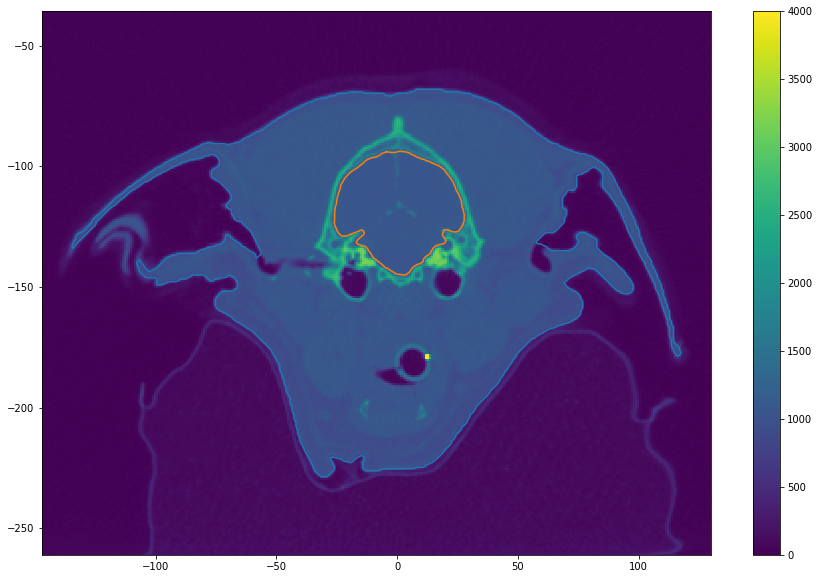

In [13]:
diagnostic_plotting(x_grid, y_grid, input_array, output_array)